# Joint clustering - two breast cancer sections from Xenium

This notebook checks and jointly clusters two 10x Genomics Xenium
breast-cancer sections. It uses all biological genes in the targeted
panel, compares BANKSY spatial weights from 0 to 1, applies Harmony
across replicates, and selects `lambda=0.2` for alignment.

The recorded run uses every QC-passing cell: 161,995 Rep1 cells and
117,630 Rep2 cells.

**Fixed-seed reproducibility.** This workflow uses seed `1000`. The runner passes it directly to PCA, Harmony, UMAP and Leiden. Use the same input observations and workflow parameters to reproduce the reported output.

## Input and preprocessing settings

Download the cell-feature H5 matrix and matching cells CSV for both the
[10x Xenium 1.0.1 Rep1](https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_analysis_summary.html)
and [Rep2](https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep2/Xenium_FFPE_Human_Breast_Cancer_Rep2_analysis_summary.html) datasets.
Files from the same Xenium release must be paired. CSV metadata is aligned
to H5 barcode order, and cell identities and transcript totals are validated.

Only the 313 `Gene Expression` features are retained. The workflow
removes 159 blank codewords, 41 negative-control codewords and 28
negative-control probes. Cells require at least 20 gene counts, at
least 10 detected genes and at most 5% control counts. Counts are
normalized to 10,000 per cell and `log1p` transformed; raw counts
remain in `layers["counts"]`. No HVG selection is used because this
is a targeted 313-gene panel.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os
import subprocess
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)


def locate_repository(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "tools" / "run_breast_cancer_xenium_clustering.py").is_file()
        ):
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


REPO_ROOT = locate_repository(Path.cwd())
RUNNER = REPO_ROOT / "tools" / "run_breast_cancer_xenium_clustering.py"
DATA_DIR = Path(os.environ.get("SPALIGNDE_XENIUM_DATA_DIR", "data/xenium_breast_cancer"))
SOURCE_DIR = Path(os.environ.get("SPALIGNDE_XENIUM_CELLS_DIR", DATA_DIR))
OUTPUT_DIR = Path(
    os.environ.get(
        "SPALIGNDE_BREAST_CANCER_CLUSTER_OUTPUT",
        "outputs/breast_cancer_xenium",
    )
)

## Input checks, QC and lambda sweep

BANKSY features are built independently within each sample with 30
spatial neighbors, `scaled_gaussian` decay and `max_m=1`. For each
lambda, the combined representation is reduced to 30 PCs, corrected
with Harmony (`sample_id`, `theta=4`, 30 iterations), and clustered
with a 50-neighbor Leiden graph at resolution 0.3.

Set `SPALIGNDE_RUN_XENIUM_CLUSTERING=1` to force recomputation. When
standard outputs are absent, the cell below also runs automatically.

In [2]:
required_output = OUTPUT_DIR / "batch_and_cluster_metrics.csv"
force_run = os.environ.get("SPALIGNDE_RUN_XENIUM_CLUSTERING", "0") == "1"
if force_run or not required_output.exists():
    execution_mode = "fresh fixed-seed recomputation"
    command = [
        sys.executable,
        str(RUNNER),
        "--data-dir", str(DATA_DIR),
        "--source-dir", str(SOURCE_DIR),
        "--output-dir", str(OUTPUT_DIR),
        "--lambdas", "0", "0.2", "0.5", "0.8", "1",
        "--seed", str(WORKFLOW_SEED),
    ]
    subprocess.run(command, check=True)
else:
    execution_mode = "validated fixed-seed artifacts"

with (OUTPUT_DIR / "run_config.json").open() as handle:
    run_config = json.load(handle)
if int(run_config["random_state"]) != WORKFLOW_SEED:
    raise ValueError(
        "The selected clustering artifacts were not produced with "
        f"the required seed {WORKFLOW_SEED}."
    )

qc = pd.read_csv(OUTPUT_DIR / "qc_summary.csv")
print("Execution mode:", execution_mode)
print("Validated artifact seed:", run_config["random_state"])
display(qc)

[2026-09-05 09:18:23] Reading and auditing Xenium Rep1


[2026-09-05 09:18:24] Reading and auditing Xenium Rep2


[2026-09-05 09:18:24] Normalizing 279,625 cells x 313 genes with target_sum=10000


[2026-09-05 09:18:28] Wrote /path/to/paper_recheck_20260905/breast_cancer/xenium_rep1_rep2_preprocessed_313genes.h5ad
[2026-09-05 09:18:28] Initializing BANKSY spatial weights for Rep1 (161,995 cells)



Median distance to closest cell = 9.527456434677378

---- Ran median_dist_to_nearest_neighbour in 0.23 s ----

---- Ran generate_spatial_distance_graph in 0.97 s ----

---- Ran row_normalize in 0.27 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 2.73 s ----

---- Ran generate_spatial_distance_graph in 1.71 s ----

---- Ran theta_from_spatial_graph in 0.72 s ----

---- Ran row_normalize in 0.27 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 4.40 s ----

[2026-09-05 09:18:41] Initializing BANKSY spatial weights for Rep2 (117,630 cells)


...

[2026-09-05 09:57:29] Computing UMAP and Leiden for lambda=1


[2026-09-05 10:11:33] lambda=1: same-batch NN 0.675 -> 0.585; iLISI 1.644 -> 1.787; clusters=8


[2026-09-05 10:12:03] Completed all lambda values. Results: /path/to/paper_recheck_20260905/breast_cancer


Execution mode: fresh fixed-seed recomputation
Validated artifact seed: 1000


,sample_id,n_cells_before,n_cells_after_qc,n_cells_used,n_removed_qc,pct_removed_qc,removed_low_counts,removed_low_detected_genes,removed_high_control_fraction
0,Rep1,167780,161995,161995,5785,0.034480,5757,4215,120
1,Rep2,118752,117630,117630,1122,0.009448,1099,537,40


Rep1 has 167,780 cells before QC and 161,995 afterward. Rep2 has
118,752 cells before QC and 117,630 afterward. The raw input thus
contains 286,532 cells, and 279,625 are used for clustering.

In [3]:
metrics = pd.read_csv(OUTPUT_DIR / "batch_and_cluster_metrics.csv")
mixing = metrics.pivot(
    index="lambda",
    columns="stage",
    values=["same_batch_knn30", "mean_ilisi"],
)
mixing.columns = [
    f"{metric}_{stage.replace('_harmony', '')}"
    for metric, stage in mixing.columns
]
display(mixing.reset_index().round(3))

,lambda,same_batch_knn30_after,same_batch_knn30_before,mean_ilisi_after,mean_ilisi_before
0,0.0,0.532,0.574,1.848,1.788
1,0.2,0.542,0.603,1.838,1.750
2,0.5,0.559,0.645,1.824,1.689
3,0.8,0.580,0.673,1.797,1.646
4,1.0,0.585,0.675,1.787,1.644


Lower same-batch 30-NN and higher iLISI indicate better batch
mixing. Harmony improves both metrics at every lambda. `lambda=0`
mixes best but removes all spatial contribution; residual sample
structure increases for `lambda>=0.5`. We therefore retain
`lambda=0.2` as a modest spatial contribution with good mixing.

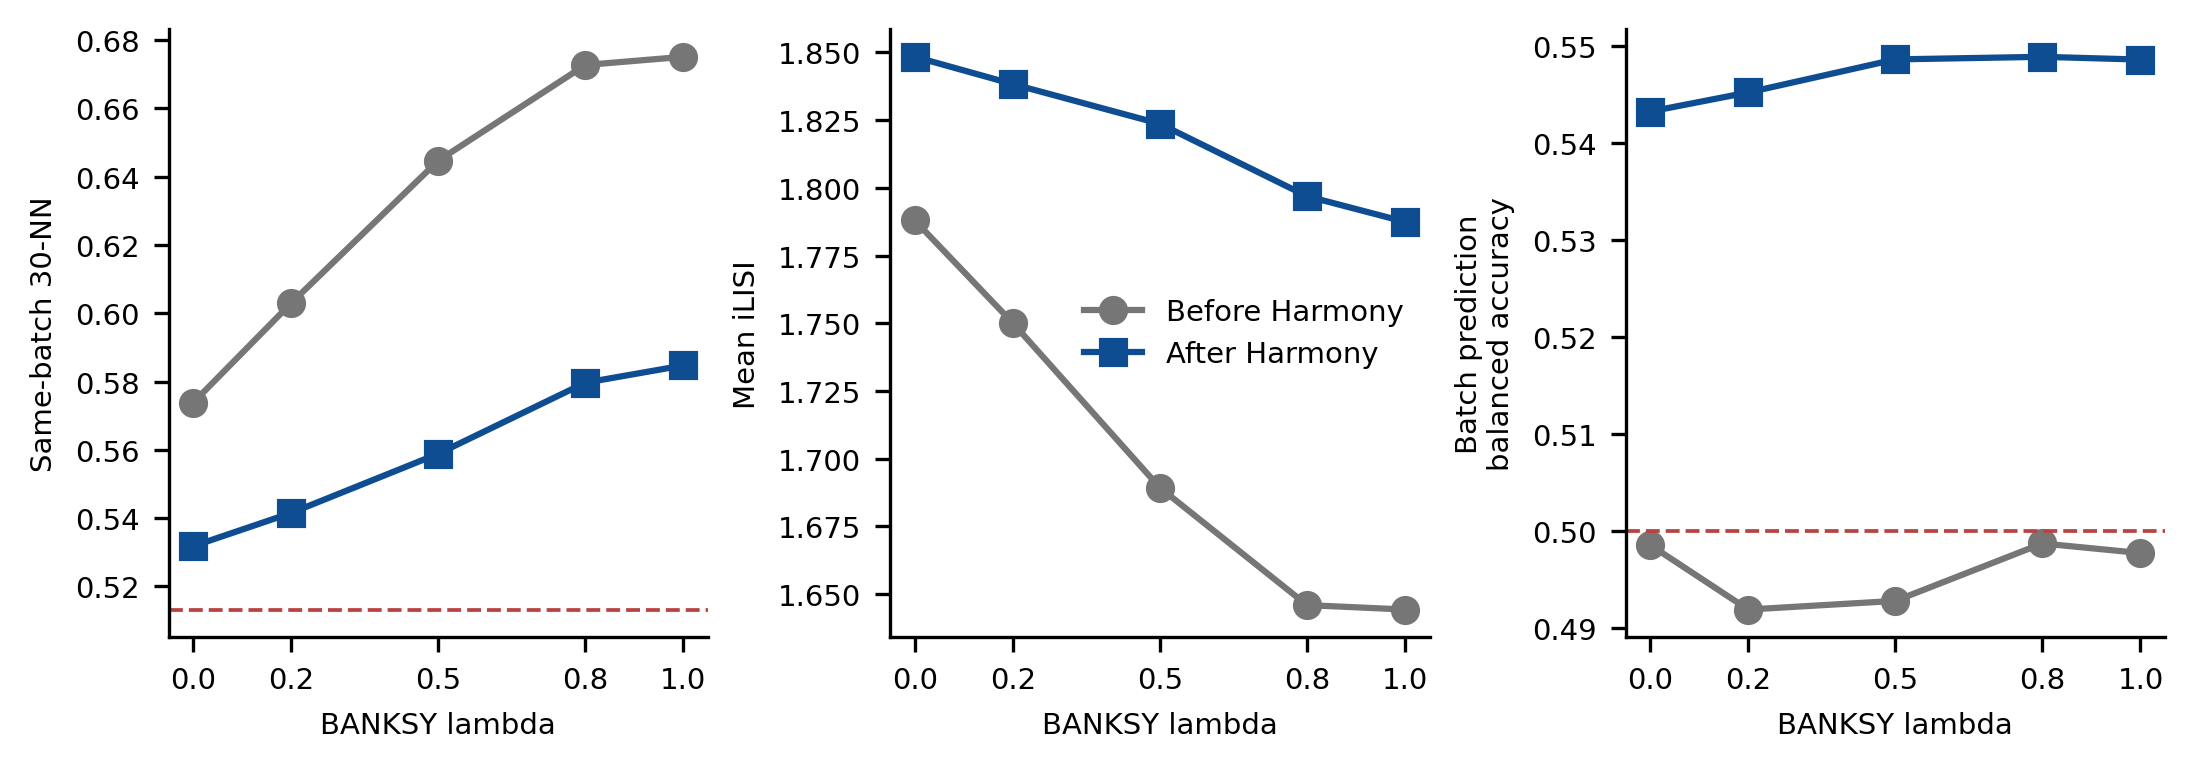

In [4]:
display(Image(filename=OUTPUT_DIR / "batch_metrics_by_lambda.png"))

## Select lambda 0.2 and export the clustered AnnData

The selected result has 10 shared Leiden clusters. Cluster labels,
PCA, Harmony and UMAP coordinates are joined back to the normalized
313-gene AnnData without changing `obsm["spatial"]`.

In [5]:
selected_dir = OUTPUT_DIR / "lambda_0p2"
adata = ad.read_h5ad(OUTPUT_DIR / "xenium_rep1_rep2_preprocessed_313genes.h5ad")
embedding = ad.read_h5ad(selected_dir / "embeddings_and_clusters.h5ad")
if not adata.obs_names.equals(embedding.obs_names):
    raise ValueError("Preprocessed and embedding cell IDs differ")

labels = embedding.obs["leiden_harmony"].astype(str).to_numpy()
adata.obs["leiden_harmony"] = pd.Categorical(labels)
adata.obs["cluster"] = pd.Categorical(labels)
for key in (
    "X_pca_banksy",
    "X_harmony_banksy",
    "X_umap_before_harmony",
    "X_umap_after_harmony",
):
    adata.obsm[key] = np.asarray(embedding.obsm[key]).copy()
adata.uns["clustering"] = {
    "method": "BANKSY + Harmony + Leiden",
    "banksy_lambda": 0.2,
    "harmony_theta": 4.0,
    "leiden_resolution": 0.3,
    "n_clusters": int(adata.obs["cluster"].nunique()),
    "hvg_selection": False,
    "n_genes": int(adata.n_vars),
}
clustered_path = selected_dir / "breast_cancer_Rep1_Rep2_lambda_0p2_clustered.h5ad"
adata.write_h5ad(clustered_path, compression="gzip")
cluster_counts = pd.crosstab(adata.obs["cluster"], adata.obs["sample_id"])
display(cluster_counts)
print(adata)

sample_id,Rep1,Rep2
cluster,,
0,21036,13876
1,17312,13713
2,12663,9637
3,13750,10780
4,647,564
5,29748,22639
6,20139,20437
7,3955,3321
8,38130,18917


AnnData object with n_obs × n_vars = 279625 × 313
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'n_genes_by_counts', 'gene_counts_from_h5', 'control_counts_from_h5', 'control_fraction', 'leiden_harmony', 'cluster'
    var: 'feature_type'
    uns: 'log1p', 'preprocessing', 'clustering'
    obsm: 'spatial', 'X_pca_banksy', 'X_harmony_banksy', 'X_umap_before_harmony', 'X_umap_after_harmony'
    layers: 'counts'


## Batch mixing and spatial cluster inspection

The first panel compares the selected representation before and
after Harmony. The second verifies that the 10 Leiden labels form
coherent spatial domains in both sections. UMAP mixing is a batch
diagnostic; preservation of spatial domains is checked separately.

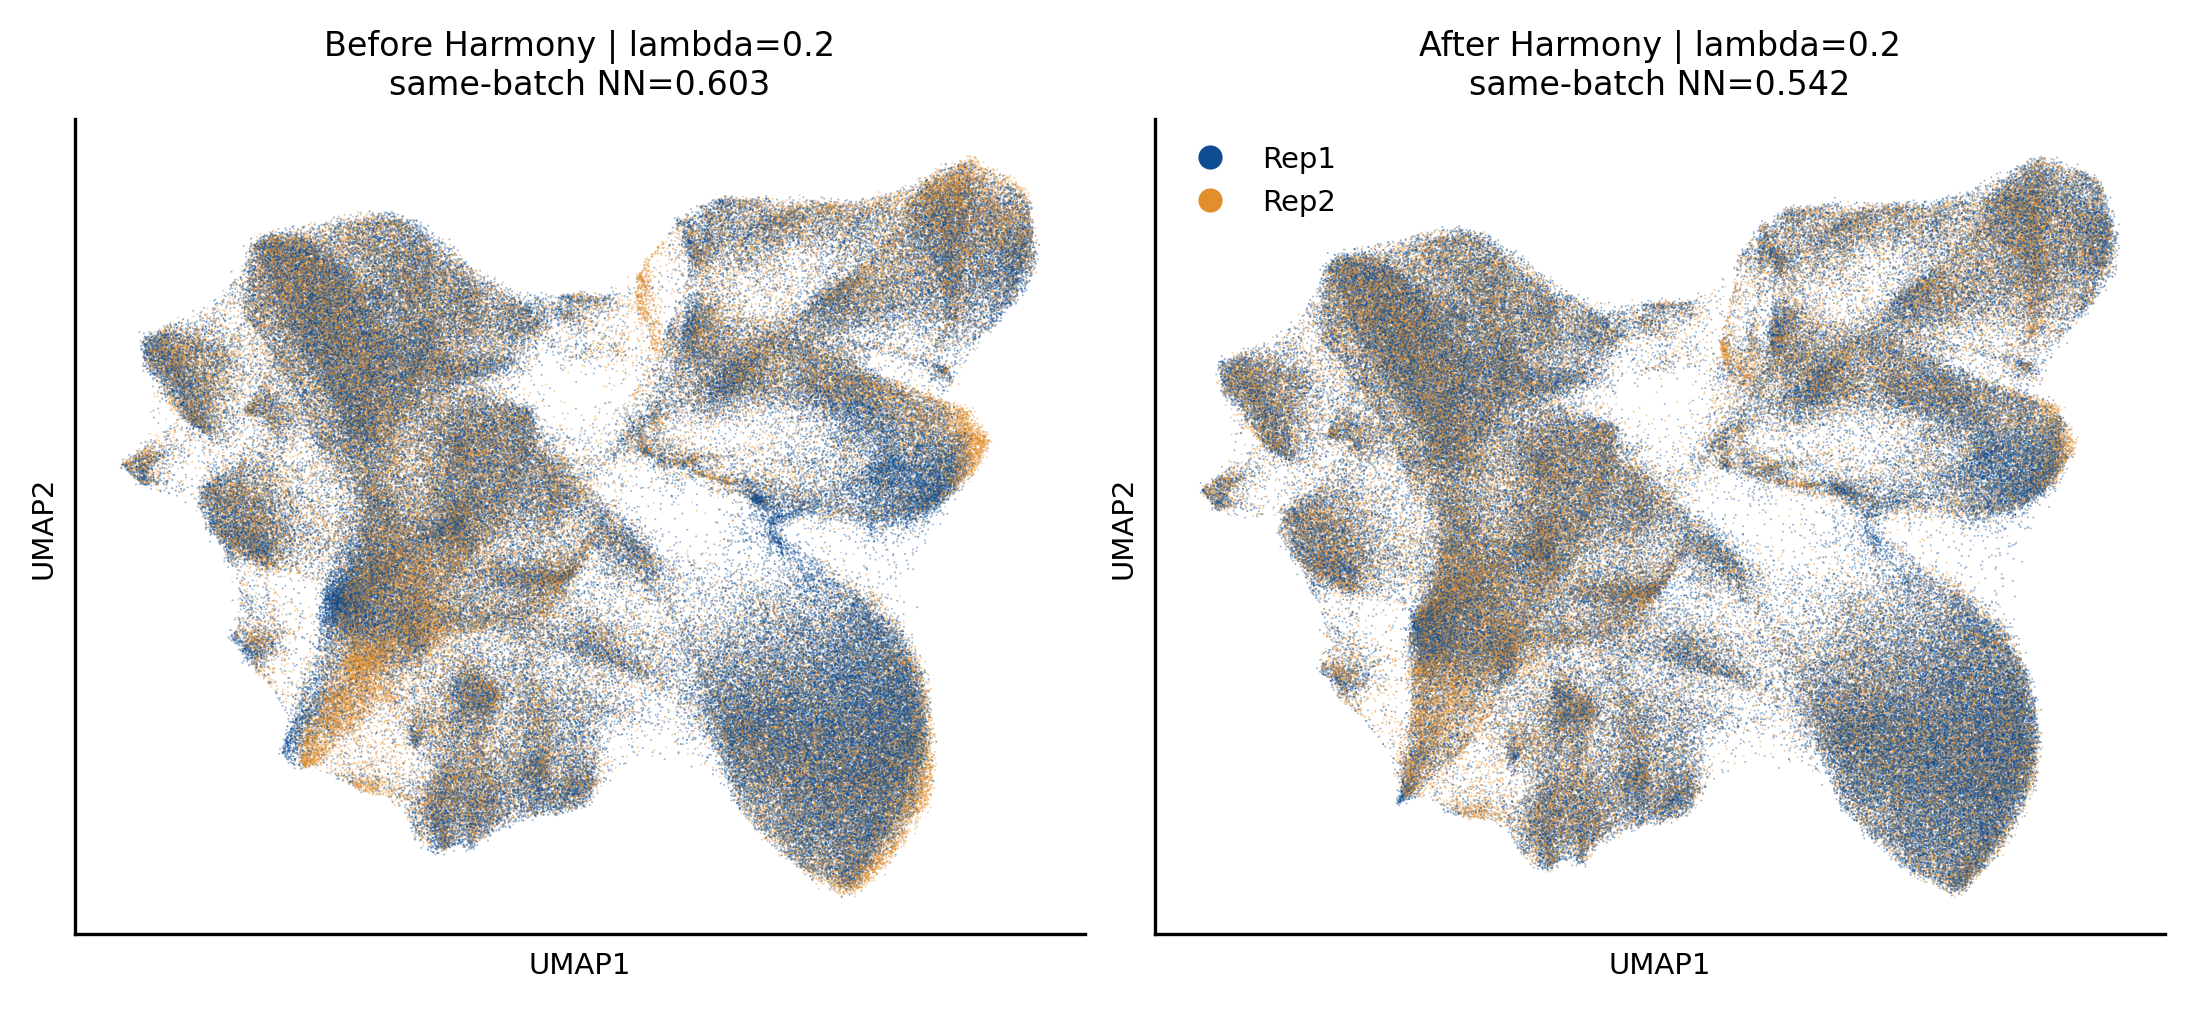

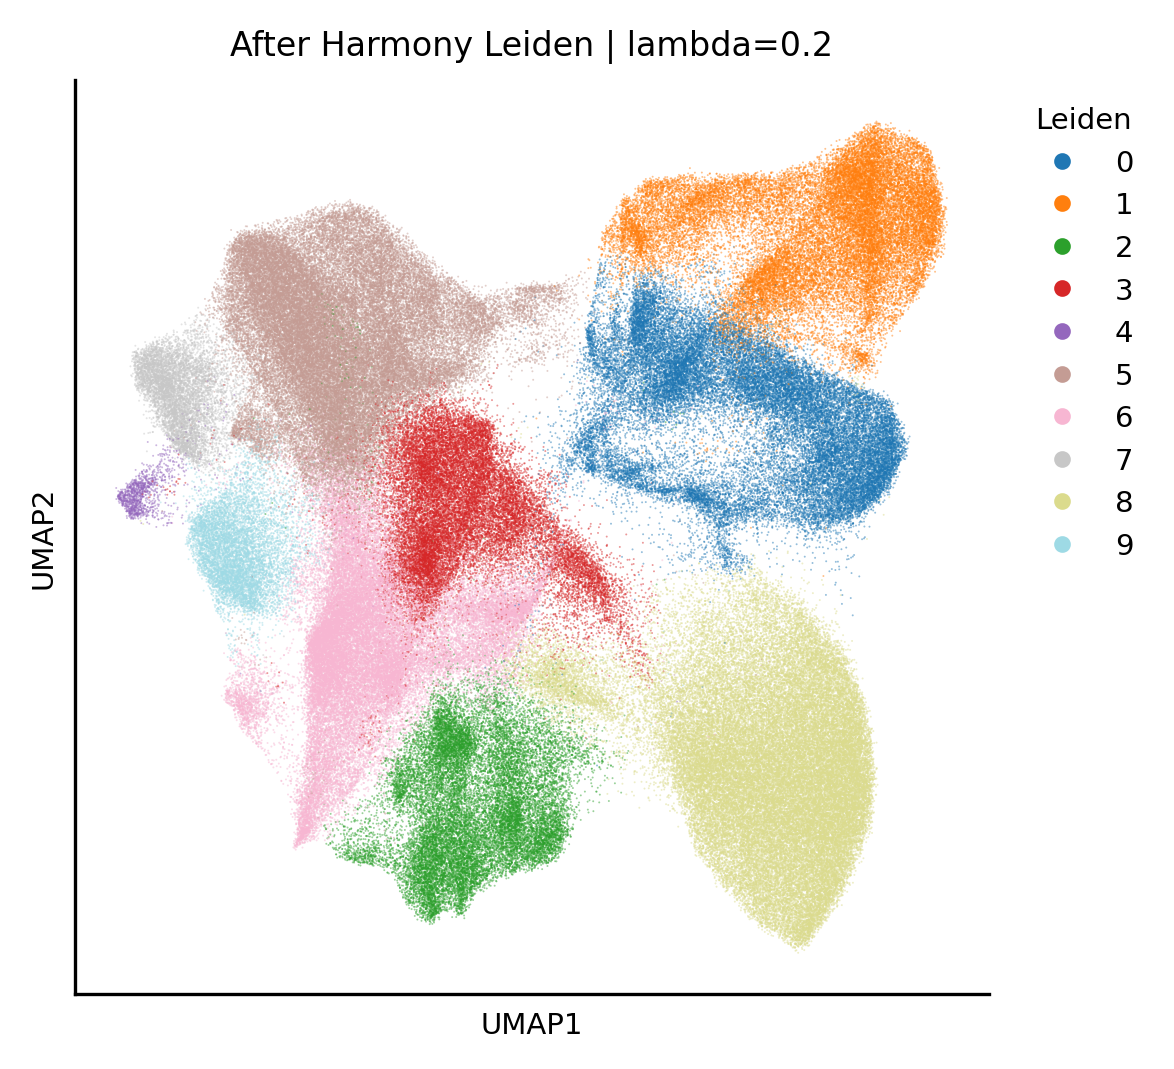

In [6]:
display(Image(filename=selected_dir / "umap_before_after_lambda_0p2.png"))
display(Image(filename=selected_dir / "umap_clusters_lambda_0p2.png"))

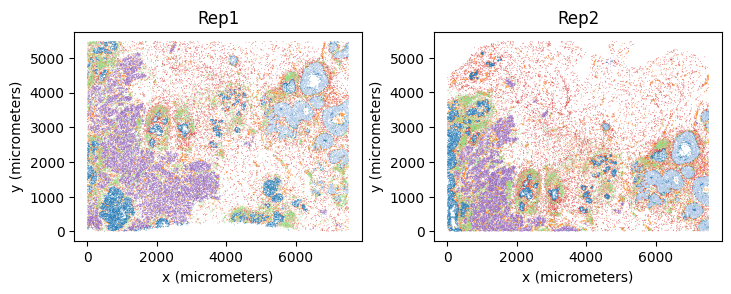

In [7]:
palette = dict(zip(sorted(adata.obs["cluster"].astype(str).unique()), plt.cm.tab20.colors))
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), constrained_layout=True)
rng = np.random.default_rng(WORKFLOW_SEED)
for ax, sample_id in zip(axes, ["Rep1", "Rep2"]):
    mask = adata.obs["sample_id"].astype(str).eq(sample_id).to_numpy()
    positions = np.flatnonzero(mask)
    if len(positions) > 70000:
        positions = np.sort(rng.choice(positions, 70000, replace=False))
    xy = np.asarray(adata.obsm["spatial"])[positions]
    labels = adata.obs["cluster"].astype(str).to_numpy()[positions]
    ax.scatter(
        xy[:, 0], xy[:, 1], c=[palette[label] for label in labels],
        s=0.25, linewidths=0, rasterized=True,
    )
    ax.set(title=sample_id, xlabel="x (micrometers)", ylabel="y (micrometers)")
    ax.set_aspect("equal")
plt.show()

The selected post-Harmony representation has same-batch 30-NN
`0.542`, mean iLISI
`1.838` and 10 Leiden clusters. The exported
clustered H5AD is the input to the alignment notebook; no HVG
subset is introduced between clustering and alignment.